<a href="https://colab.research.google.com/github/Bokenasubi-T/pomacea-distribution-jp/blob/main/notebooks/01_download_and_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01. Download and clean GBIF records of *Pomacea canaliculata* in Japan

- Input: GBIF occurrence API
- Output: `data/pomacea_jp_clean.csv`

In [ ]:
#install library for collecting data from GBIF
!pip install pygbif

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 3.6 MB/s eta 0:00:00


In [ ]:
# Search GBIF for Pomacea canaliculata records in Vietnam
from pygbif import occurrences
import pandas as pd

res = occurrences.search(
    scientificName="Pomacea canaliculata",
    country="VN",
    hasCoordinate=True,
    limit=300,
)

print("Total records in Vietnam", res["count"])

df = pd.DataFrame(res["results"])
df[["scientificName", "decimalLatitude", "decimalLongitude",
    "eventDate", "basisOfRecord"]].head(10)

Total records in Vietnam 12


,scientificName,decimalLatitude,decimalLongitude,eventDate,basisOfRecord
0,"Pomacea canaliculata (Lamarck, 1822)",20.300000,105.900000,2025-05-11T20:58Z,HUMAN_OBSERVATION
1,"Pomacea canaliculata (Lamarck, 1822)",11.951049,108.450256,2020-02-15T00:00,HUMAN_OBSERVATION
2,"Pomacea canaliculata (Lamarck, 1822)",15.089453,108.718002,NaN,MATERIAL_CITATION
3,"Pomacea canaliculata (Lamarck, 1822)",21.355848,107.122261,NaN,MATERIAL_CITATION
4,"Pomacea canaliculata (Lamarck, 1822)",20.851213,106.689974,NaN,MATERIAL_CITATION
5,"Pomacea canaliculata (Lamarck, 1822)",19.233859,104.920328,NaN,MATERIAL_CITATION
6,"Pomacea canaliculata (Lamarck, 1822)",16.509474,107.595672,NaN,MATERIAL_CITATION
7,"Pomacea canaliculata (Lamarck, 1822)",10.032833,105.763749,NaN,MATERIAL_CITATION
8,"Pomacea canaliculata (Lamarck, 1822)",9.952567,105.353463,NaN,MATERIAL_CITATION
9,"Pomacea canaliculata (Lamarck, 1822)",10.375665,106.338665,NaN,MATERIAL_CITATION


The number of records in Vietnam was smaller than expected (12 records, 10 of which are from literature). Therefore, I compared record counts across countries.

In [ ]:
#compare record counts across countries
countries = ["VN", "JP", "TH", "PH", "TW", "CN", "KR"]

for code in countries:
  r = occurrences.search(
      scientificName="Pomacea canaliculata",
      country = code,
      hasCoordinate=True,
      limit=0,
  )
  print(code, r["count"])

VN 12
JP 293
TH 22
PH 42
TW 298
CN 209
KR 357


I chose Japan because it has many more records than Vietnam and I am familiar with its environment.

In [ ]:
#Download all data from Japan
all_results = []
offset = 0

while True:
  r = occurrences.search(
      scientificName="Pomacea canaliculata",
      country="JP",
      hasCoordinate=True,
      limit=300,
      offset=offset,
  )

  all_results.extend(r["results"])
  if r["endOfRecords"]:
    break
  offset += 300

df_jp = pd.DataFrame(all_results)
print("Number of records:", len(df_jp))
print(df_jp["basisOfRecord"].value_counts())
print(df_jp["year"].describe())

Number of records: 293
basisOfRecord
HUMAN_OBSERVATION     218
PRESERVED_SPECIMEN     51
MATERIAL_CITATION      19
MATERIAL_SAMPLE         5
Name: count, dtype: int64
count     259.000000
mean     2018.671815
std         8.832003
min      1982.000000
25%      2016.000000
50%      2021.000000
75%      2025.000000
max      2026.000000
Name: year, dtype: float64


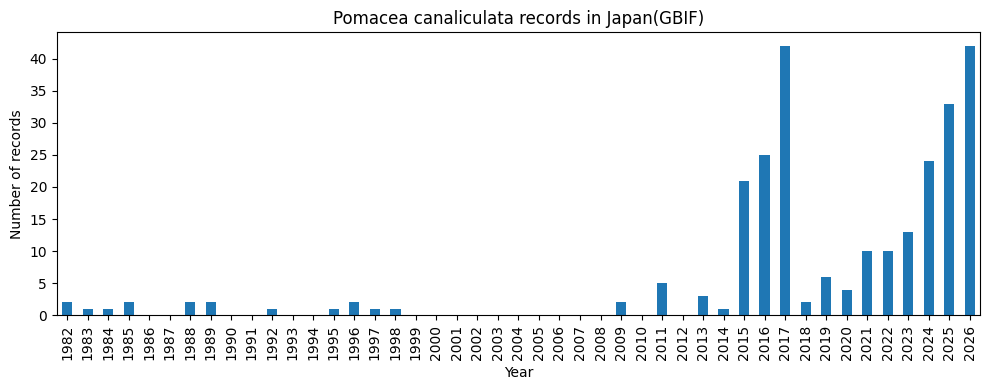

In [ ]:
# Plot the number of records per year (bar chart)

import matplotlib.pyplot as plt

years = df_jp["year"].dropna().astype(int) # Drop missing years and convert to integers

counts = years.value_counts().sort_index()
counts = counts.reindex(range(years.min(), years.max()+1), fill_value=0)

counts.plot(kind="bar", figsize=(10,4))
plt.xlabel("Year")
plt.ylabel("Number of records")
plt.title("Pomacea canaliculata records in Japan(GBIF)")
plt.tight_layout()
plt.show()

In [ ]:
# Visualize raw occurrence points on an interactive map
import folium

m = folium.Map(location=[36,138], zoom_start=5, tiles=None) #Around centre of Japan

folium.TileLayer(
    tiles="https://cyberjapandata.gsi.go.jp/xyz/pale/{z}/{x}/{y}.png",
    attr='<a href="https://maps.gsi.go.jp/development/ichiran.html">地理院タイル</a>',
    name="GSI pale map",
).add_to(m)

for _, row in df_jp.iterrows():
  color = "red" if row["basisOfRecord"] == "HUMAN_OBSERVATION" else "blue"
  folium.CircleMarker(
      location=[row["decimalLatitude"], row["decimalLongitude"]],
      radius=5,
      color=color,
      fill=True,
      fill_color=color,
  ).add_to(m)
m

In [ ]:
# Categorize records by period
bins = [0, 2010, 2018, 2026]
labels = ["-2010", "2011-2018", "2019-2026"]
df_jp["period"] = pd.cut(df_jp["year"], bins=bins, labels=labels)
df_jp["period"] = df_jp["period"].cat.add_categories("Unknown").fillna("Unknown")

print(df_jp["period"].value_counts())

colors = {"-2010": "blue", "2011-2018": "orange", "2019-2026": "red", "Unknown": "gray"}

# Base map
m = folium.Map(location=[36, 138], zoom_start=5, tiles=None)
folium.TileLayer(
    tiles="https://cyberjapandata.gsi.go.jp/xyz/pale/{z}/{x}/{y}.png",
    attr='<a href="https://maps.gsi.go.jp/development/ichiran.html">地理院タイル</a>',
    name="GSI pale map",
).add_to(m)

# One layer per period (can be switched on/off)
groups = {p: folium.FeatureGroup(name=p).add_to(m) for p in colors}

for _, row in df_jp.iterrows():
    p = row["period"]
    folium.CircleMarker(
        location=[row["decimalLatitude"], row["decimalLongitude"]],
        radius=5,
        color=colors[p],
        fill=True,
        fill_color=colors[p],
        popup=f"year: {row['year']} / {row['basisOfRecord']}",
    ).add_to(groups[p])

folium.LayerControl(collapsed=False).add_to(m)
m

period
2019-2026    142
2011-2018     99
Unknown       34
-2010         18
Name: count, dtype: int64


Many records in Kyushu were collected in 2011–2018. To check whether a specific event or survey caused this pattern, I examined the datasets and observers in this period.

In [ ]:
mask = df_jp["period"] == "2011-2018"

# Which datasets are the records from?
print(df_jp.loc[mask, "datasetName"].value_counts())

# Who recorded them?
print(df_jp.loc[mask, "recordedBy"].value_counts().head(10))

datasetName
iNaturalist research-grade observations    9
Name: count, dtype: int64
recordedBy
harum.koh          6
Motohiro Kawase    5
まふゆのうじ             1
hakkahamushi       1
Takaaki Hattori    1
Name: count, dtype: int64


In [ ]:
# Include missing values (NaN) in the counts, and check datasets by datasetKey
print(df_jp.loc[mask, "datasetName"].value_counts(dropna=False))
print(df_jp.loc[mask, "recordedBy"].value_counts(dropna=False).head(10))

print(df_jp.loc[mask,"datasetKey"].value_counts())
print(df_jp.loc[mask, "basisOfRecord"].value_counts())

In [ ]:
# Look up the names of the datasets from their keys
from pygbif import registry
key =["45ff6ac5-ee78-48dd-997f-3602025bc562","810e15d2-f762-11e1-a439-00145eb45e9a","50c9509d-22c7-4a22-a47d-8c48425ef4a7"]

titles =[]

for i in key:
  titles.append(registry.datasets(uuid=i)["title"])


titles


['A dataset of molluscan fauna sampled in estuaries of medium and small rivers in Kyushu, Japan',
 'Molluscus specimens of Toyohashi Museum of Natural History',
 'iNaturalist Research-grade Observations']

The spike in Kyushu during 2011–2018 is mainly due to a single survey dataset (molluscan fauna in estuaries of rivers in Kyushu, 70 of 99 records). This reflects sampling effort rather than an actual increase in the population.

In [ ]:
#check the survey design of 'A dataset of molluscan fauna sampled in estuaries of medium and small rivers in Kyushu, Japan'
ds = registry.datasets(uuid="45ff6ac5-ee78-48dd-997f-3602025bc562")
print(ds.get("description"))
print(ds.get("samplingDescription"))

cols = ["eventID", "samplingProtocol", "sampleSizeValue", "sampleSizeUnit", "habitat", "locality"]
df_jp.loc[df_jp["datasetKey"] == "45ff6ac5-ee78-48dd-997f-3602025bc562",
          [c for c in cols if c in df_jp.columns]].head(10)

In [ ]:
# Diagnose potential problems in the coordinates
df =df_jp.copy() # to keep original dataset, make a copy and edit it

# 1. check warning flags by GBIF
print("===GBIF issue flags===")
print(df["issues"].explode().value_counts())

# 2. Coordinate uncertainty (m)
print("\n=== Coordinate uncertainty (m)===")
print(df["coordinateUncertaintyInMeters"].describe())
print("Missing:", df["coordinateUncertaintyInMeters"].isna().sum())

# 3. Decimal places of coordinates (fewer digits = coarser location)
def n_decimals(x):
  decimals = str(float(x)).split(".")[1].rstrip("0")
  return len(decimals)

df["precision"] = df[["decimalLatitude", "decimalLongitude"]].map(n_decimals).min(axis=1)
print("\n===decimal places of coordinates ===")
print(df["precision"].value_counts().sort_index())

# 4. Check Duplicates
print("\n=== Duplicates ===")
print("Same coordinates and date:", df.duplicated(subset=["decimalLatitude","decimalLongitude","eventDate"]).sum())

===GBIF issue flags===
issues
CONTINENT_DERIVED_FROM_COORDINATES                  263
COORDINATE_ROUNDED                                  138
TAXON_ID_NOT_FOUND                                  137
GEODETIC_DATUM_ASSUMED_WGS84                         71
OCCURRENCE_STATUS_INFERRED_FROM_INDIVIDUAL_COUNT     71
TAXON_MATCH_FUZZY                                    70
INSTITUTION_MATCH_FUZZY                              50
INSTITUTION_COLLECTION_MISMATCH                      33
GEODETIC_DATUM_INVALID                               30
INSTITUTION_MATCH_NONE                               24
COLLECTION_MATCH_FUZZY                               15
INDIVIDUAL_COUNT_INVALID                              3
TAXON_CONCEPT_ID_NOT_FOUND                            3
COLLECTION_MATCH_NONE                                 2
Name: count, dtype: int64

=== Coordinate uncertainty (m)===
count       116.000000
mean      18237.086207
std       84733.237199
min           1.000000
25%           4.000000
50%       

In [ ]:
# Check species names (the issue flags implied a risk of mixing with other species)
print(df["scientificName"].value_counts())

# Check records with coordinate uncertainty over 1 km
print(df.loc[df["coordinateUncertaintyInMeters"]>1000,["coordinateUncertaintyInMeters", "locality", "basisOfRecord", "year"]])

scientificName
Pomacea canaliculata (Lamarck, 1822)    290
BOLD:AAA3844                              3
Name: count, dtype: int64
     coordinateUncertaintyInMeters locality      basisOfRecord    year
0                         452936.0      NaN  HUMAN_OBSERVATION  2026.0
1                         456301.0      NaN  HUMAN_OBSERVATION  2026.0
3                         468241.0      NaN  HUMAN_OBSERVATION  2026.0
4                         472007.0      NaN  HUMAN_OBSERVATION  2026.0
17                          1366.0      NaN  HUMAN_OBSERVATION  2026.0
39                         55321.0      NaN  HUMAN_OBSERVATION  2026.0
42                          1052.0      NaN  HUMAN_OBSERVATION  2025.0
67                         28620.0      NaN  HUMAN_OBSERVATION  2025.0
77                         28592.0      NaN  HUMAN_OBSERVATION  2024.0
88                         28984.0      NaN  HUMAN_OBSERVATION  2024.0
136                        28734.0      NaN  HUMAN_OBSERVATION  2019.0
142                

In [ ]:
# Clean the data step by step, recording how many records are removed
clean = df_jp.copy()
log = [("Raw data", len(clean))]

# 1. Keep only Pomacea canaliculata
clean = clean[clean["scientificName"].str.startswith("Pomacea canaliculata")]
log.append(("Taxon filter", len(clean)))

# 2. Remove records with coordinate uncertainty > 1 km (keep missing values)
clean = clean[~(clean["coordinateUncertaintyInMeters"] > 1000)]
log.append(("Uncertainty <= 1 km", len(clean)))

# 3. Remove duplicates (same coordinates and date)
clean = clean.drop_duplicates(subset=["decimalLatitude", "decimalLongitude", "eventDate"])
log.append(("Remove duplicates", len(clean)))

pd.DataFrame(log, columns=["Step", "Records"])


,Step,Records
0,Raw data,293
1,Taxon filter,290
2,Uncertainty <= 1 km,275
3,Remove duplicates,260


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Keep only the columns needed for analysis
keep_cols = ["gbifID", "scientificName", "decimalLatitude", "decimalLongitude",
             "coordinateUncertaintyInMeters", "eventDate", "year", "basisOfRecord",
             "datasetKey", "datasetName", "stateProvince", "locality", "period"]
clean_out = clean[[c for c in keep_cols if c in clean.columns]]

# Save to CSV
import os
os.makedirs("/content/drive/MyDrive/Colab Notebooks/pomacea/data", exist_ok=True)

path = "/content/drive/MyDrive/Colab Notebooks/pomacea/data/pomacea_jp_clean.csv"
clean_out.to_csv(path, index=False)
print("Saved:", path, len(clean_out), "records")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved: /content/drive/MyDrive/Colab Notebooks/pomacea/data/pomacea_jp_clean.csv 260 records
